# Unconstrained optimization

This page demonstrates how to minimize an unconstrained continuous function. First, the minimize method must be imported.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from smt_optim import minimize

## Unconstrained optimization of a 1D function

### Defining the test problem

The following example shows how to minimize the `xsinx` function over a bounded domain. This can be formulated as:

$$
\min_{x\in\mathbb{R}^1} \quad (x - 3.5)\sin\left(\frac{x-3.5}{\pi}\right) \quad \text{s.t.} \quad 0 \leq x \leq 25.
$$

The cell below defines and plots the function.


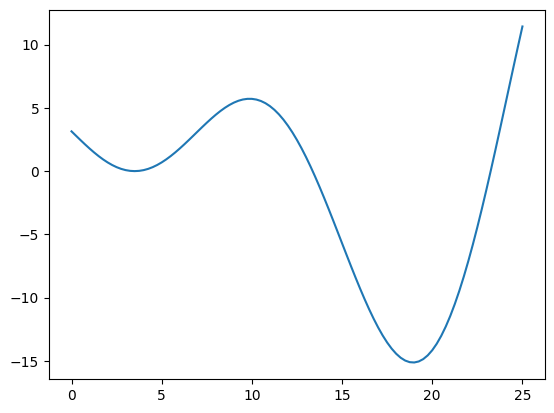

In [2]:
def xsinx(x):
    return (x - 3.5) * np.sin((x - 3.5) / (np.pi))

bounds = np.array([
    [0, 25]
])

x_valid = np.linspace(0, 25, 101)
y_valid = xsinx(x_valid)

fig, ax = plt.subplots()
ax.plot(x_valid, y_valid)
plt.show()

### Starting the optimization

The easiest way to begin Bayesian optimization is to use the `minimize` method. Two arguments must be passed:

- `objective`: the function to minimize;
- `design_space`: the function boundary.

Because the `objective` parameter requires a list, we place our objective function within a list. The `design_space` parameter can accept either a `DesignSpace` class or a `np.ndarray`. Providing a `np.ndarray` will assume the design space is entirely continuous.

Moreover, we can also pass the following optional arguments:

- `max_iter`: the maximum number of iterations before the program stops
- `driver_kwargs`: kwargs to pass to the optimization driver. In our case, we pass the `seed` parameter to make this example reproducible.

All minimize parameters can be viewed using: help(minimize). The minimize method returns a State object containing the design of experiment (DoE) with all function samples. We can find the best function value during the optimization process using these samples.


In [3]:
state = minimize([xsinx], bounds, max_iter=12, driver_kwargs={"seed": 0})

          iter         budget           fmin           rscv       fidelity        gp_time       acq_time
             1              6   -6.00738e+00      0.000e+00              1          0.034          0.038
             2              7   -1.30604e+01      0.000e+00              1          0.019          0.027
             3              8   -1.30604e+01      0.000e+00              1          0.032          0.008
             4              9   -1.30604e+01      0.000e+00              1          0.026          0.012
             5             10   -1.30604e+01      0.000e+00              1          0.052          0.006
             6             11   -1.30604e+01      0.000e+00              1          0.040          0.007
             7             12   -1.42711e+01      0.000e+00              1          0.036          0.007
             8             13   -1.42711e+01      0.000e+00              1          0.028          0.007
             9             14   -1.42711e+01      0.000

We can retrieve the best function sample using the `get_best_sample` class method. This returns a `Sample` object containing data such as:

- `x`: the design point
- `obj`: the objective value at `x`
- `eval_time`: the elapsed time to sample the objective.

The `Sample` object also contains some metadata:

- `iter`: the iteration at which the function was sampled
- `budget`: the budget after sampling the function

By default, one unit of budget is equivalent to one function evaluation.


In [4]:
best_sample = state.get_best_sample()
best_sample

======= sample data =======
x =             [18.61626614]
obj =           [-15.04184845]
cstr =          []
eval_time =     [6.74900002e-06]
------- meta data -------
iter =     12
budget =     17
fidelity =     0
rscv =     0.0

### Plotting the results

The code snippet below exports all the evaluated design points and their corresponding objective values, plotting them against the function. The best sample is marked with a star.

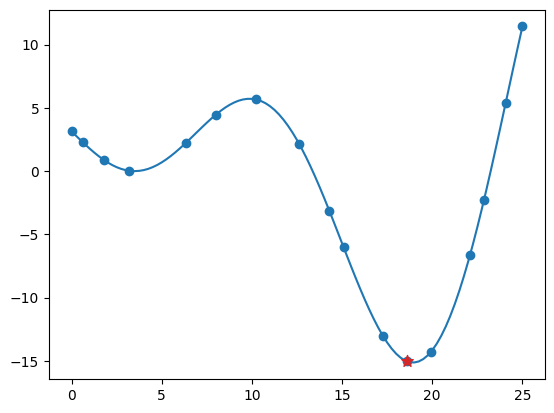

In [5]:
x_doe = state.dataset.export_as_dict()["x"]
y_doe = state.dataset.export_as_dict()["obj"]

fig, ax = plt.subplots()
ax.plot(x_valid, y_valid)
ax.scatter(x_doe, y_doe)
ax.scatter(best_sample.x[0], best_sample.obj[0], 75, color="C3", marker="*", zorder=30)
plt.show()